In [1]:
# Part A - MLP on Fashion-MNIST
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [2]:
# Data normalization and loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Train-validation split (80-20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))


100.0%
100.0%
100.0%
100.0%


Train samples: 48000
Validation samples: 12000


In [3]:
# MLP Model with 2 hidden layers
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLP().to(device)
print(model)


MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss and optimizer defined")


Loss and optimizer defined


In [5]:
train_losses = []
val_losses = []

epochs = 10

for epoch in range(epochs):
    # Training
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")


Epoch [1/10] - Train Loss: 0.5194, Val Loss: 0.3985
Epoch [2/10] - Train Loss: 0.3838, Val Loss: 0.3740
Epoch [3/10] - Train Loss: 0.3382, Val Loss: 0.3491
Epoch [4/10] - Train Loss: 0.3181, Val Loss: 0.3395
Epoch [5/10] - Train Loss: 0.2933, Val Loss: 0.3324
Epoch [6/10] - Train Loss: 0.2771, Val Loss: 0.3299
Epoch [7/10] - Train Loss: 0.2599, Val Loss: 0.3226
Epoch [8/10] - Train Loss: 0.2478, Val Loss: 0.3255
Epoch [9/10] - Train Loss: 0.2345, Val Loss: 0.3341
Epoch [10/10] - Train Loss: 0.2223, Val Loss: 0.3417


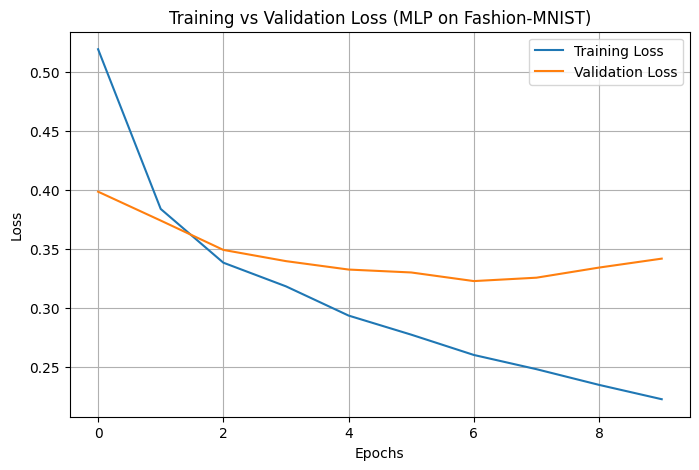

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (MLP on Fashion-MNIST)")
plt.legend()
plt.grid(True)

# Save the plot in the correct folder
plt.savefig("loss_curves.png")
plt.show()
